In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [22]:
df_temperatura = pd.read_csv("./celsius_a_fahrenheit.csv")

print(df_temperatura.head())

   Celsius  Fahrenheit
0      -50       -58.0
1      -40       -40.0
2      -30       -22.0
3      -20        -4.0
4      -10        14.0


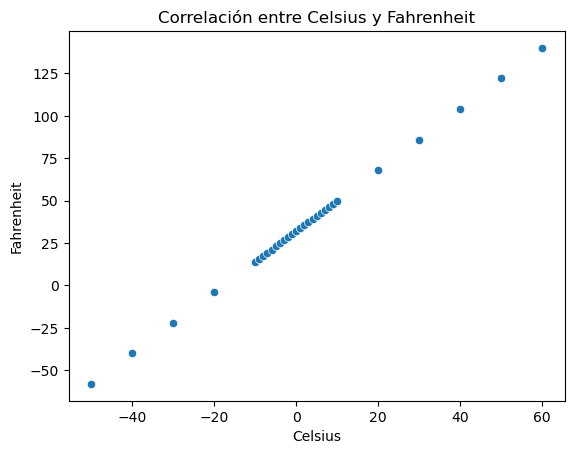

In [23]:
sns.scatterplot(x="Celsius", y="Fahrenheit", data=df_temperatura)
plt.title("Correlación entre Celsius y Fahrenheit")
plt.show()

In [24]:
X_train = np.array(df_temperatura["Celsius"], dtype=float)
Y_train = np.array(df_temperatura["Fahrenheit"], dtype=float)

print("Creando el modelo")
model = tf.keras.Sequential([tf.keras.layers.Dense(units=1, input_shape=[1])])
model.compile(optimizer=tf.keras.optimizers.Adam(1.0), loss="mean_squared_error")
hist1 = model.fit(X_train, Y_train, epochs=100, verbose=False)

Creando el modelo


In [25]:
oculta1 = tf.keras.layers.Dense(units=3, input_shape=[1])
oculta2 = tf.keras.layers.Dense(units=3)
salida = tf.keras.layers.Dense(units=1)

modelo = tf.keras.Sequential([oculta1, oculta2, salida])
modelo.compile(optimizer=tf.keras.optimizers.Adam(1.0), loss="mean_squared_error")

Entrenando el modelo parte 2
Epoch 1/100
1/1 [==============================] - 0s 425ms/step - loss: 2414.8398
Epoch 2/100
1/1 [==============================] - 0s 4ms/step - loss: 23645.3418
Epoch 3/100
1/1 [==============================] - 0s 4ms/step - loss: 60130.4141
Epoch 4/100
1/1 [==============================] - 0s 5ms/step - loss: 3470.7642
Epoch 5/100
1/1 [==============================] - 0s 5ms/step - loss: 6245.5762
Epoch 6/100
1/1 [==============================] - 0s 3ms/step - loss: 4316.9966
Epoch 7/100
1/1 [==============================] - 0s 4ms/step - loss: 7229.7476
Epoch 8/100
1/1 [==============================] - 0s 4ms/step - loss: 18441.8184
Epoch 9/100
1/1 [==============================] - 0s 3ms/step - loss: 954.2508
Epoch 10/100
1/1 [==============================] - 0s 5ms/step - loss: 24555.2051
Epoch 11/100
1/1 [==============================] - 0s 3ms/step - loss: 2068.5537
Epoch 12/100
1/1 [==============================] - 0s 3ms/step - loss: 7

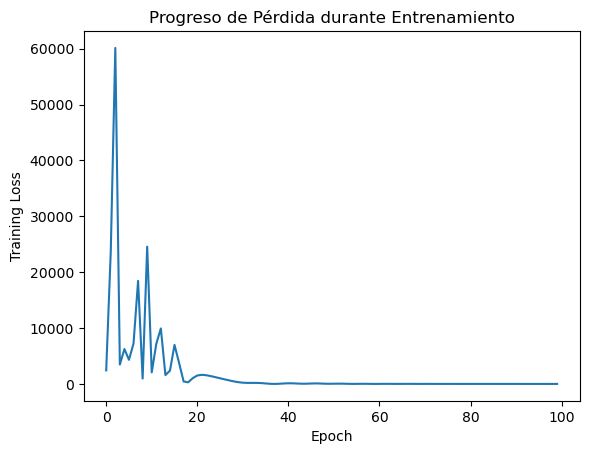

In [26]:
print("Entrenando el modelo parte 2")
epochs_hist = modelo.fit(X_train, Y_train, epochs=100)

print(oculta1.get_weights())
print(oculta2.get_weights())
print(salida.get_weights())

print("Keys: ", epochs_hist.history.keys())

plt.plot(epochs_hist.history["loss"])
plt.title("Progreso de Pérdida durante Entrenamiento")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.show()

Temperatura predicha : [[211.26682]]
Temperatura ecuación : 212.0


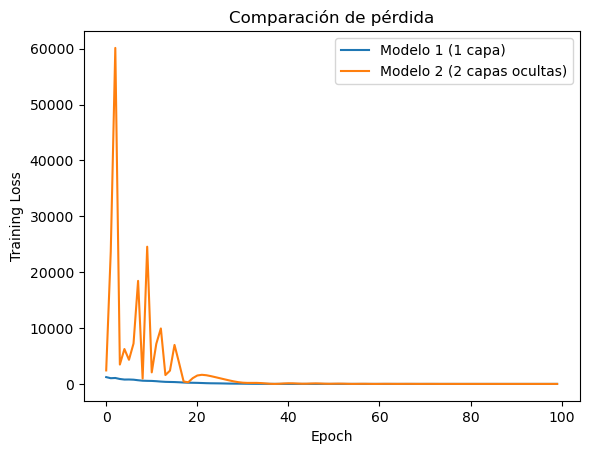

In [27]:
Temp_C = 100
Temp_F_pred = modelo.predict(np.array([[Temp_C]]), verbose=0)
Temp_F_real = 9 / 5 * Temp_C + 32

print("Temperatura predicha : " + str(Temp_F_pred))
print("Temperatura ecuación : " + str(Temp_F_real))

# Comparación de pérdidas
plt.plot(hist1.history["loss"], label="Modelo 1 (1 capa)")
plt.plot(epochs_hist.history["loss"], label="Modelo 2 (2 capas ocultas)")
plt.title("Comparación de pérdida")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.show()

Modelo 1 - Epoch 100: 0.0791 | Modelo 2 - Epoch 100: 0.3322
Modelo 1 - Epoch 150: 0.0004 | Modelo 2 - Epoch 150: 0.0007
Modelo 1 - Epoch 200: 0.0000 | Modelo 2 - Epoch 200: 0.0000
Modelo 1 - Epoch 300: 0.0000 | Modelo 2 - Epoch 300: 0.0000
Modelo 1 - Epoch 400: 0.0000 | Modelo 2 - Epoch 400: 0.0000
Modelo 1 - Epoch 500: 0.0000 | Modelo 2 - Epoch 500: 0.0000


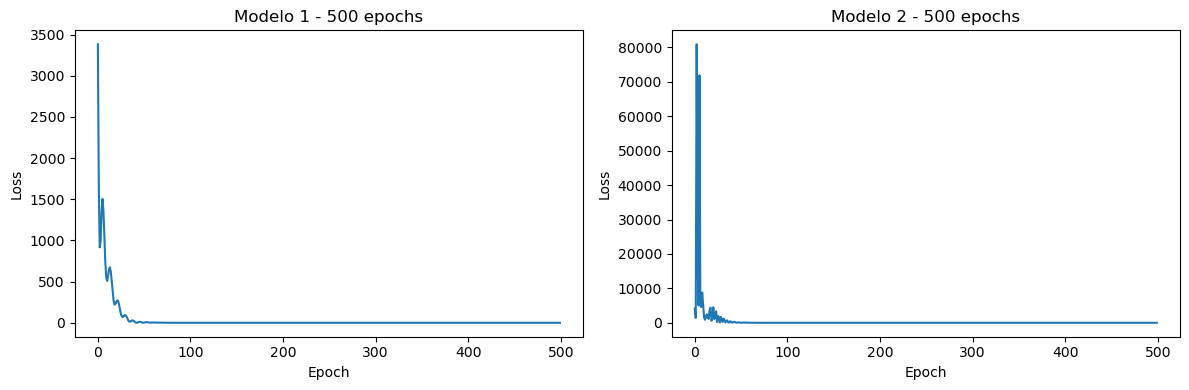

In [28]:
# Código para responder la pregunta 3: 

# Reentrenar con más epochs para encontrar el punto de convergencia
model2 = tf.keras.Sequential([tf.keras.layers.Dense(units=1, input_shape=[1])])
model2.compile(optimizer=tf.keras.optimizers.Adam(1.0), loss="mean_squared_error")
hist_extended1 = model2.fit(X_train, Y_train, epochs=500, verbose=False)

oculta1b = tf.keras.layers.Dense(units=3, input_shape=[1])
oculta2b = tf.keras.layers.Dense(units=3)
salidab = tf.keras.layers.Dense(units=1)
model2b = tf.keras.Sequential([oculta1b, oculta2b, salidab])
model2b.compile(optimizer=tf.keras.optimizers.Adam(1.0), loss="mean_squared_error")
hist_extended2 = model2b.fit(X_train, Y_train, epochs=500, verbose=False)

# Imprimir pérdidas en puntos clave
for e in [100, 150, 200, 300, 400, 500]:
    print(
        f"Modelo 1 - Epoch {e}: {hist_extended1.history['loss'][e-1]:.4f} | "
        f"Modelo 2 - Epoch {e}: {hist_extended2.history['loss'][e-1]:.4f}"
    )

# Gráfica
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist_extended1.history["loss"])
ax1.set_title("Modelo 1 - 500 epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2.plot(hist_extended2.history["loss"])
ax2.set_title("Modelo 2 - 500 epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")

plt.tight_layout()
plt.show()

Predicción con ReLU  : 35.6
Valor real (fórmula) : 212.0


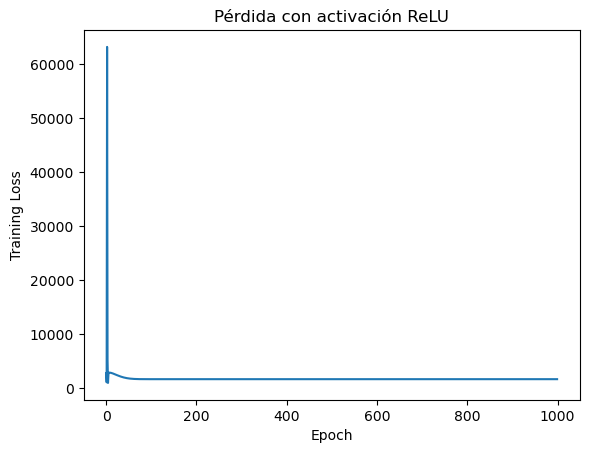

In [29]:
# Código para responder la pregunta 5:
oculta1_relu = tf.keras.layers.Dense(units=3, input_shape=[1], activation="relu")
oculta2_relu = tf.keras.layers.Dense(units=3, activation="relu")
salida_relu = tf.keras.layers.Dense(units=1)

modelo_relu = tf.keras.Sequential([oculta1_relu, oculta2_relu, salida_relu])
modelo_relu.compile(optimizer=tf.keras.optimizers.Adam(1.0), loss="mean_squared_error")

hist_relu = modelo_relu.fit(X_train, Y_train, epochs=1000, verbose=False)

pred_relu = modelo_relu.predict(np.array([[100]]), verbose=0)
print("Predicción con ReLU  :", pred_relu[0][0])
print("Valor real (fórmula) :", 9 / 5 * 100 + 32)

plt.plot(hist_relu.history["loss"])
plt.title("Pérdida con activación ReLU")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.show()

## Análisis y Discusión de Preguntas

**1.**
Adam sirve para ajustar automáticamente la tasa de aprendizaje, siendo el más rápido y estable. Por otro lado, SGD es el más simple pero aprende más lento y puede atascarse. Y finalmente, RMSProp adapta la tasa según el historial reciente. Cambiar a SGD requeriría más epochs para converger, mientras que RMSProp daría resultados similares a Adam.

**2.**
El mean_squared_error se utiliza para medir el promedio de errores al cuadrado, penalizando más los errores grandes. Alternativas como mean_absolute_error son menos sensibles a valores atípicos, y huber combina ambas siendo más robusta. Dependiendo de tu elección de cuál de éstos utilizar, terminaría afectando qué tan agresivamente el modelo corrige sus errores.

**3.**
Observando las gráficas de pérdida con 500 epochs, ambos modelos siguen descendiendo más allá de las 100 epochs originales. En el Modelo 1, la pérdida pasa de 0.04 en la epoch 100 a prácticamente 0 en la epoch 200. En el Modelo 2 ocurre lo mismo, con la pérdida llegando a 0 cerca de la epoch 200. Por lo tanto, las 100 epochs originales no son suficientes; ambos modelos necesitan aproximadamente 150-200 epochs para converger completamente.

**4.**
Las epochs determinan cuántas veces el modelo revisa los datos para ajustar sus pesos, usar pocas genera underfitting y demasiadas sería overfitting. El número adecuado es donde la pérdida deja de disminuir.

**5.**
Las capas Dense usan activación lineal por defecto, adecuada para regresión ya que la salida puede ser cualquier número. Es posible cambiarla a ReLU agregando activation='relu' en las capas ocultas, que solo activa neuronas con valores positivos. Sin embargo, al implementarla, podemos observar que el modelo no converge correctamente, incluso después de 1000 epochs, prediciendo 35.6°F en lugar de 212°F. Esto se debe a que ReLU desactiva neuronas con valores negativos, y como los datos de entrenamiento incluyen temperaturas bajo cero, el modelo pierde información clave. Esto confirma que la activación lineal es más adecuada para este tipo de problema de regresión.

